# Analysis of nuclide and flux relaxation in RM schemes

In [ ]:
import CustomSchemes
from CustomSchemes import SIE
from CustomSchemes.SIE import load_SIE as load_SIE
import matplotlib.pyplot as plt

In [ ]:
the_file = SIE.SIE().get_from_pkl("FLUX.pkl")

In [ ]:
the_file.plot_all_x()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_x_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_fx_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
the_file.x[0.0][0]


# Anderson Acceleration analysis

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
import matplotlib.pyplot as plt
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')

In [ ]:
time = 3.0
for this in aa.fx[time]:
  plt.plot(this)

In [ ]:
aa.get

In [ ]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=3.0, file='aa2_i4_t3.pkl', k_max=4, m=2, dpi=100)

# Visual comparison of each

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')
flux = SIE().get_from_pkl('FLUX.pkl')
nuclide = SIE().get_from_pkl('NUCLIDE.pkl')


In [ ]:
def difference(x, ref) -> np.ndarray:
  return np.array([1-x[idx]/ref[idx] for idx in range(len(ref))])

time = 0.5
plt.figure(figsize=(5,3), dpi=250)
plt.plot(flux.x[time][-1], 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(nuclide.x[time][-1], 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(aa.x[time][-1], 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()

time = 0.5
ref = flux.x[time][-1]
aa_x = aa.x[time][-1]
nuc_x = nuclide.x[time][-1]

plt.figure(figsize=(5,3), dpi=250)
plt.plot(difference(ref, ref), 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(difference(nuc_x, ref), 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(difference(aa_x, ref), 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()


# Results for a single step

In [8]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import matplotlib.pyplot as plt
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i100_t2.pkl')

from CustomSchemes.DumbTransport import flat_transport

x = aa.get_x_by_iteration(time=325.0)

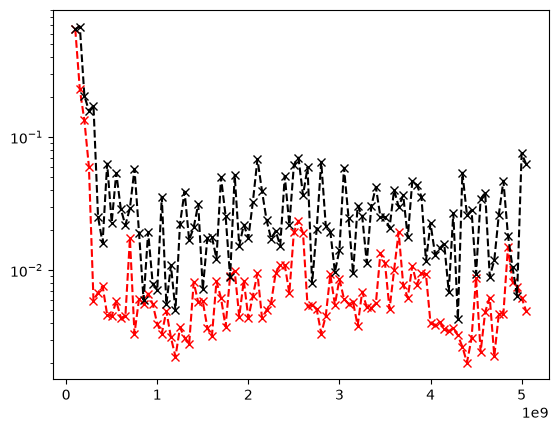

In [24]:
def get_norm(x: np.ndarray, xref: np.ndarray, order: int = 2) -> float:
  return (np.linalg.norm(x - xref, ord=order)/np.linalg.norm(x, ord=order))

ref = flat_transport(16)
x = aa.get_x_by_iteration(time=325.0)
fx = aa.get_fx_by_iteration(time=325.0)

x_old = x[0]
fx_old = fx[0]

resids_x = []
resids_fx = []
total_histories = [100000*500]

for idx, this_x in enumerate(x[1:]):
  resids_x.append(get_norm(this_x, ref))
  x_old = this_x
  total_histories.append(100000*500 + total_histories[-1])

for idx, this_fx in enumerate(fx[0:]):
  resids_fx.append(get_norm(this_fx, ref))
  fx_old = this_fx

plt.plot(total_histories[1:], resids_x, 'rx--')
plt.plot(total_histories[1:], resids_fx, 'kx--')
plt.yscale('log')
# plt.xscale('log')

Computed fixed point (last x_next) =  [0.06285951 0.06278863 0.06285908 0.06268738 0.06246085 0.06250012
 0.06218733 0.06230932 0.06246933 0.06258979 0.06265685 0.06295358
 0.06257643 0.06223559 0.06206745 0.06179875]
Last n_next value from vector x =  [0.06285951 0.06278863 0.06285908 0.06268738 0.06246085 0.06250012
 0.06218733 0.06230932 0.06246933 0.06258979 0.06265685 0.06295358
 0.06257643 0.06223559 0.06206745 0.06179875]
Iterations: 100
Alpha sums are == 1.0
Alphas = [ 0.85509459 -0.61803157  0.76293698]


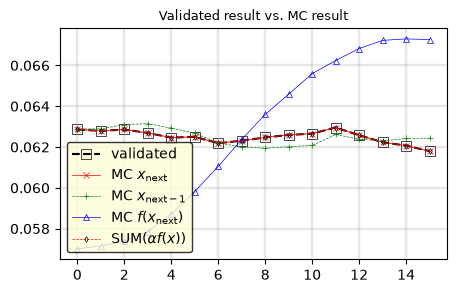

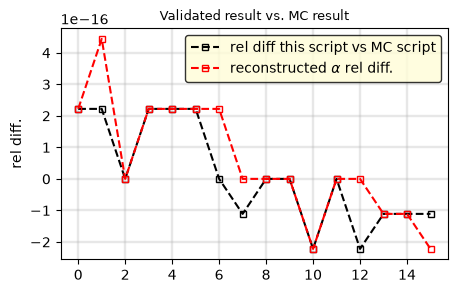

In [14]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=325.0, file='aa2_i100_t2.pkl', k_max=100, m=2, dpi=100)